In [1]:
import sys
import os

sys.path.insert(0, os.path.abspath('..'))
import photospline
from icecube import dataio, icetray, dataclasses, simclasses, phys_services
import numpy.random as random
import numpy as np
import scipy.optimize as optimize
from scripts.SplineEval import evalPdf

In [2]:
file_500 = dataio.I3File('../nue_data/gen_500.i3.zst')
file_012 = dataio.I3File('../nue_data/gen_012.i3.zst')
gcd = dataio.I3File('../gcdfile/PONE_800mGrid.i3.gz')

In [3]:
iter = 0
for frame in file_500:
    if iter == 17:
        frame18 = frame
    if iter == 26:
        frame27 = frame

    if iter == 92:
        frame93 = frame
    if iter == 127:
        frame128 = frame
    iter += 1
iter = 0
for frame in file_012:
    if iter == 69:
        frame70 = frame
    iter += 1

In [6]:
len(frame93['I3Photons'])

25

In [5]:
for frame in gcd:
    gcdframe = frame
    break

In [8]:
spline = photospline.SplineTable('/mnt/home/dillonb5/cascades/fits/splinelog.fits')
tgrid = np.linspace(spline.extents[1][0], spline.extents[1][1], 1000)
N_GROUP = 1.34
N_PHASE = 1.35557

rng = np.random.default_rng()
def resample(frame):
    stats = dict(events=0, doms=0, pulses=0, doms_clamped=0, doms_skipped=0, bad_doms = 0)
    if "I3Photons" not in frame or "I3MCTree" not in frame:
        return True
    electron = dataclasses.I3Particle(frame["I3MCTree"][1])
    # mu.shape = dataclasses.I3Particle.InfiniteTrack
    geo = gcdframe["I3ModuleGeoMap"]
    old = frame["I3Photons"]
    omkeys = frame['I3Photons'].keys()
    new = simclasses.I3CompressedPhotonSeriesMap()
    stats["events"] += 1

    for omkey, series in old.items():
        stats['doms'] += 1
        if omkey not in geo:
            new[omkey] = series
            stats['bad_doms'] += 1
            continue
        pos = geo[omkey].pos
        dist = phys_services.I3Calculator.cherenkov_distance(electron, pos, N_GROUP, N_PHASE)
        # d_eval = min(max(dist, DLO + 1e-6), DHI - 1e-6)
        # if d_eval != dist:
        #     stats["doms_clamped"] += 1
        pdf = np.clip(np.exp(spline.evaluate_simple([tgrid, dist])), 0.0, None)
        tot = pdf.sum()
        if not np.isfinite(tot) or tot <= 0:
            stats["doms_skipped"] += 1
            new[omkey] = series          # keep original times, nothing to sample from
            continue
        cdf = np.cumsum(pdf); cdf /= cdf[-1]

        ns = simclasses.I3CompressedPhotonSeries()
        rows = []
        for p in series:
            old_tres = phys_services.I3Calculator.time_residual(electron, pos, p.time, N_GROUP, N_PHASE)
            new_tres = float(np.interp(rng.random(), cdf, tgrid))
            rows.append((p.time - old_tres + new_tres, p.weight, p.wavelength, p.dir.zenith, p.dir.azimuth, p.pos))
            stats["pulses"] += 1
        rows.sort(key=lambda r: r[0])
        for t, w, lamb, zen, az, pos in rows:
            np_ = simclasses.I3CompressedPhoton()
            np_.time, np_.weight, np_.wavelength, np_.dir, np_.pos = t, w, lamb, dataclasses.I3Direction(zen, az), pos
            ns.append(np_)
        new[omkey] = ns
        #new[omkey] = rows

    del frame['new_photons']
    frame['new_photons'] = new
    #print(f"frame {frame['I3EventHeader'].event_id} Working")
    return stats

In [9]:
resample(frame18)

{'events': 1,
 'doms': 70,
 'pulses': 11126,
 'doms_clamped': 0,
 'doms_skipped': 0,
 'bad_doms': 0}

In [10]:
print(frame18['new_photons'])

[ModuleKey(198,16) => [[I3CompressedPhoton: 
        Time: 1905.41
      Weight: 1
  Wavelength: 4.50432e-07
      Zenith: 1.49007
     Azimuth: 0.849763
    Position: (-0.00841193,0.200812,0.0786469)
  Group Vel.: -1.0842e-19
  ParticleID: 0,-1)]],
ModuleKey(199,13) => [[I3CompressedPhoton: 
        Time: 1298.88
      Weight: 1
  Wavelength: 4.54734e-07
      Zenith: 0.84239
     Azimuth: 1.27781
    Position: (0.186041,-0.00367417,0.109487)
  Group Vel.: -3.68935e+19
  ParticleID: 0,-1)]],
ModuleKey(199,14) => [[I3CompressedPhoton: 
        Time: 1656.15
      Weight: 1
  Wavelength: 4.46653e-07
      Zenith: 1.24018
     Azimuth: 1.15911
    Position: (0.152357,0.099482,-0.116192)
  Group Vel.: -3.68935e+19
  ParticleID: 0,-1)], [I3CompressedPhoton: 
        Time: 2154.04
      Weight: 1
  Wavelength: 4.40453e-07
      Zenith: 1.22338
     Azimuth: 1.16486
    Position: (0.143039,0.15445,-0.0479281)
  Group Vel.: 0
  ParticleID: 0,-1)], [I3CompressedPhoton: 
        Time: 2208.09
 

In [114]:
c=0
for omkey, photon in frame18['I3Photons']:
    print(omkey)
    print(photon)
    c += 1
    if c == 4:
        break

ModuleKey(198,16)
[[I3CompressedPhoton: 
        Time: 1055.02
      Weight: 1
  Wavelength: 4.50432e-07
      Zenith: 1.49007
     Azimuth: 0.849763
    Position: (-0.00841193,0.200812,0.0786469)
  Group Vel.: 0.217002
  ParticleID: 15941211553967342775,614)]]
ModuleKey(199,13)
[[I3CompressedPhoton: 
        Time: 758.374
      Weight: 1
  Wavelength: 4.54734e-07
      Zenith: 0.84239
     Azimuth: 1.27781
    Position: (0.186041,-0.00367417,0.109487)
  Group Vel.: 0.217143
  ParticleID: 15941211553967342775,614)]]
ModuleKey(199,14)
[[I3CompressedPhoton: 
        Time: 646.234
      Weight: 1
  Wavelength: 4.40453e-07
      Zenith: 1.22338
     Azimuth: 1.16486
    Position: (0.143039,0.15445,-0.0479281)
  Group Vel.: 0.216653
  ParticleID: 15941211553967342775,614)], [I3CompressedPhoton: 
        Time: 635.818
      Weight: 1
  Wavelength: 4.46653e-07
      Zenith: 1.24018
     Azimuth: 1.15911
    Position: (0.152357,0.099482,-0.116192)
  Group Vel.: 0.216873
  ParticleID: 159412115

In [6]:
c = 299792458
n = 1.33
def datacollect(frame):
    dt = []
    t = []
    dphilst = []
    dr = []
    xyz = []
    Etheta = []
    Ephi = []

    Epos = frame['I3MCTree'][1].pos
    doms = gcdframe['I3ModuleGeoMap']
    omkeys = frame['I3Photons'].keys()
    photons = frame['I3Photons']
    electronangle = frame['I3MCTree'][1].dir
    for key in omkeys:
        modulekey = dataclasses.ModuleKey(key.string, key.om)
        dompos = doms[modulekey].pos
        for photon in photons[key]:
            photon_pos = dompos + photon.pos
            xyz.append([photon_pos.x, photon_pos.y, photon_pos.z])
            flight = dompos + photon.pos - Epos
            dr.append(flight.magnitude)
            offset = flight.magnitude * n / c
            dt.append(photon.time - offset*10**9)
            t.append(photon.time)
            phi = photon.dir
            randx, randy, randz = random.uniform(-1, 1, 3)
            x = phi.x
            y = phi.y
            z = phi.z
            dx = x - randx
            dy = y - randy
            dz = z - randz
            dphi = dataclasses.I3Direction(dx, dy, dz)
            dphilst.append(dphi.zenith)
            # Etheta.append(flight.azimuth)
            # Ephi.append(flight.zenith)
            
    return np.column_stack([xyz, t, dr, dt])
    
    

In [7]:
EventData1 = datacollect(frame18)
EventData2 = datacollect(frame27)
EventData3 = datacollect(frame70)
EventData4 = datacollect(frame93)
EventData5 = datacollect(frame128)

In [8]:
EventData1[:,-1]

array([279.46867071,  41.21136373,  47.99801549, ..., 169.41178407,
        47.97198169, 155.85704851])

In [9]:
import matplotlib.pyplot as plt

In [9]:
splinefit = photospline.SplineTable('../fits/splinelog.fits')

In [11]:
splinefit.extents

((0.9185454891739763, 300.0), (-29.021966049010643, 1628.4555514098238))

In [11]:
def displacement_magnitude(pos1: np.array, pos2: np.array) -> float:
    vector = pos1 - pos2
    return np.sqrt(vector[0]**2 + vector[1]**2 + vector[2]**2)

In [12]:
splinefit.extents

((0.9185454891739763, 300.0), (-29.021966049010643, 1628.4555514098238))

In [13]:
# This should also take xyzt for photons
# Given our data set of photons, what is the probability of making those data if we were to have an electron

def Likelihood(coords: np.array, Event: np.array = EventData1):
    L = 0
    # coords should have shape [x,y,z,t]
    # Event has shape [x,y,z,t,dr,dt,dphi,Ephi]. We only use the first 4 here
    for event in Event:
        dr = displacement_magnitude(coords[0:3], np.array(event[0:3]))
        
        dt = abs(coords[3] - event[3]) - (1.34*dr/c * 1e9)
        if (splinefit.evaluate_simple([dr, dt])) == 0:
            L += -20
        else:
            L += (splinefit.evaluate_simple([dr, dt]))
    
    
    return -(L)

In [14]:
Likelihood(np.array([2.86453, 216.537, 254.435, 0]), EventData1)

38893.5927195549

In [15]:
c = 299792458
n = 1.34
def Likelihood_per_OM(coords, frame):
    OM_likelihoods = {}
    doms = gcdframe['I3ModuleGeoMap']
    omkeys = frame['I3Photons'].keys()
    photons = frame['I3Photons']
    for key in omkeys:
        x = []
        y = []
        z = []
        t = []
        modulekey = dataclasses.ModuleKey(key.string, key.om)
        dompos = doms[modulekey].pos
        for photon in photons[key]:
            photon_pos = dompos + photon.pos
            x.append(photon_pos.x)
            y.append(photon_pos.y)
            z.append(photon_pos.z)
            t.append(photon.time)
        event = np.column_stack([x, y, z, t])
        
        OM_likelihoods[str(key)] = [Likelihood(coords, event), len(t)]
        
    return OM_likelihoods


In [16]:
def Likelihood(coords: np.array, Event):
    L = 0
    # coords should have shape [x,y,z,t]
    # Event has shape [x,y,z,t,dr,dt,dphi,Ephi]. We only use the first 4 here
    event_xyz = Event[:,0:3]
    event_t = Event[:,3]

    diff = coords[0:3] - event_xyz
    dr = np.linalg.norm(diff, axis=1)
    # Calculate Time Residual
    dt = abs(coords[-1] - event_t) - (1.34*dr/c * 1e9)

    params = np.array([dr, dt])

    vals = splinefit.evaluate_simple([params[0], params[1]])
    L = np.where(vals == 0, -30, vals)
    return -np.sum(L)

In [17]:
truth = np.array([2.86453, 216.537, 254.435, 0])
def likelihood_calculation(truth, Event) -> None:
    xary = np.linspace(truth[0] - 150, truth[0] + 150, 500)
    yary = np.linspace(truth[1] - 150, truth[1] + 150, 500)
    zary = np.linspace(truth[2] - 150, truth[2] + 150, 500)
    tary = np.linspace(truth[3] - 700, truth[3] + 700, 500)

    xplot = []
    yplot = []
    zplot = []
    tplot = []
    for i in range(len(xary)):
        xplot.append(Likelihood(np.array([xary[i], truth[1], truth[2], truth[3]]), Event=Event))
        yplot.append(Likelihood(np.array([truth[0], yary[i], truth[2], truth[3]]), Event=Event))
        zplot.append(Likelihood(np.array([truth[0], truth[1], zary[i], truth[3]]), Event=Event))
        tplot.append(Likelihood(np.array([truth[0], truth[1], truth[2], tary[i]]), Event=Event))
    return [xplot, yplot, zplot, tplot]


In [18]:
def likelihood_graphs(truth, data, filename:str):
    xary = np.linspace(truth[0] - 150, truth[0] + 150, 500)
    yary = np.linspace(truth[1] - 150, truth[1] + 150, 500)
    zary = np.linspace(truth[2] - 150, truth[2] + 150, 500)
    tary = np.linspace(truth[3] - 700, truth[3] + 700, 500)
    fig, axs = plt.subplots(2, 2)
    axs[0,0].plot(xary, data[0])
    axs[0,0].set_title('Likelihood Evolution in X')
    axs[0,0].set_xlabel('X (m)')
    axs[0,0].set_ylabel('-ln(L)')
    axs[0,0].vlines(truth[0], min(data[0]), max(data[0]), label = 'Truth', colors = 'red', ls = '--')
    axs[0,0].grid()
    # axs[0,0].set_ylim(min(data[0]) - 100, min(data[0]) + 400)
    # axs[0,0].set_xlim(truth[0] - 2.5, truth[0] + 2.5)
    #axs[0,0].set_yscale('log')
    axs[0,0].legend()


    axs[1,0].plot(yary, data[1])
    axs[1,0].set_title('Likelihood Evolution in Y')
    axs[1,0].set_xlabel('Y (m)')
    axs[1,0].set_ylabel('-ln(L)')
    axs[1,0].grid()
    # axs[1,0].set_ylim(min(data[1]) - 100, min(data[1]) + 400)
    # axs[1,0].set_xlim(truth[1] - 2.5, truth[1] + 2.5)
    #axs[1,0].set_yscale('log')
    axs[1,0].vlines(truth[1], min(data[1]), max(data[1]), label = 'Truth', colors = 'red', ls = '--')
    axs[1,0].legend()


    axs[0,1].plot(zary, data[2])
    axs[0,1].set_title('Likelihood Evolution in Z')
    axs[0,1].set_xlabel('Z (m)')
    axs[0,1].set_ylabel('-ln(L)')
    # axs[0,1].set_ylim(min(data[2]) - 100, min(data[2]) + 400)
    # axs[0,1].set_xlim(truth[2] - 2.5, truth[2] + 2.5)
    #axs[0,1].set_yscale('log')
    axs[0,1].vlines(truth[2], min(data[2]), max(data[2]), label = 'Truth', colors = 'red', ls = '--')
    axs[0,1].grid()
    axs[0,1].legend()


    axs[1,1].plot(tary, data[3])
    axs[1,1].set_title('Likelihood Evolution in t')
    axs[1,1].set_xlabel('t (ns)')
    axs[1,1].set_ylabel('-ln(L)')
    # axs[1,1].set_xlim(truth[3] - 5, truth[3] + 5)
    # axs[1,1].set_ylim(min(data[3]) - 100, min(data[3]) + 400)
    # #axs[1,1].set_yscale('log')
    axs[1,1].vlines(truth[3], min(data[3]), max(data[3]), label = 'Truth', colors = 'red', ls = '--')
    axs[1,1].grid()
    axs[1,1].legend()

    fig.tight_layout()
    fig.savefig(f'../plots/{filename}.png')

In [19]:
likelihood_data = likelihood_calculation(([2.86453, 216.537, 254.435, 0]), EventData1)

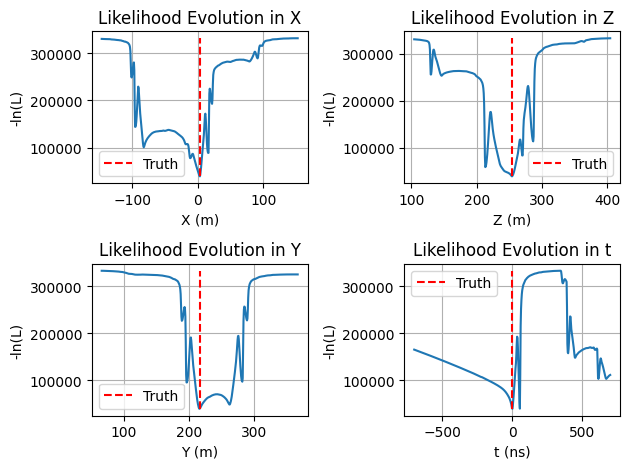

In [20]:
likelihood_graphs(np.array([2.86453, 216.537, 254.435, 0]), likelihood_data, 'file_1_likelihood_evo_v4')


In [21]:
# Take absolute positions of PMTs and time 
# Electron is moving which changes photon paths based on fixed photon hits
# takes an electron position guess, then moves the electron around based on output from likelihood to optimize
def minimizer(guess, event, function=Likelihood):
    # Guess should be xyzt
    minimized = optimize.minimize(function, 
                                  x0=guess,
                                  args=(event,),  
                                  method='Nelder-Mead', 
                                  tol=1e-3)
    return minimized

    

In [22]:
Likelihood_per_OM([2.86453, 216.537, 254.435, 0], frame18)

{'ModuleKey(198,16)': [8.40014362335205, 1],
 'ModuleKey(199,13)': [3.892451047897339, 1],
 'ModuleKey(199,14)': [16.631818771362305, 3],
 'ModuleKey(199,15)': [4.781585693359375, 1],
 'ModuleKey(200,15)': [7.473656177520752, 1],
 'ModuleKey(201,14)': [6.71826696395874, 1],
 'ModuleKey(217,14)': [3.5002455711364746, 1],
 'ModuleKey(218,12)': [3.6158299446105957, 1],
 'ModuleKey(218,13)': [11.49009084701538, 3],
 'ModuleKey(218,14)': [29.25716209411621, 7],
 'ModuleKey(218,15)': [75.9969265460968, 14],
 'ModuleKey(218,16)': [34.63639307022095, 7],
 'ModuleKey(218,17)': [5.59817361831665, 1],
 'ModuleKey(219,13)': [24.59036421775818, 5],
 'ModuleKey(219,14)': [307.30322194099426, 55],
 'ModuleKey(219,15)': [1223.1778435707092, 190],
 'ModuleKey(219,16)': [275.08628129959106, 41],
 'ModuleKey(219,17)': [24.87764549255371, 4],
 'ModuleKey(220,13)': [6.724793434143066, 1],
 'ModuleKey(220,14)': [24.10534954071045, 4],
 'ModuleKey(220,15)': [39.73847961425781, 6],
 'ModuleKey(220,16)': [27.8

In [23]:
print(frame18['I3MCTree'][1])

[ I3Particle MajorID : 15941211553967342775
             MinorID : 614
              Zenith : 1.12255
             Azimuth : 5.03732
                   X : 2.86453
                   Y : 216.537
                   Z : 254.435
                Time : 0
              Energy : 1847.28
               Speed : 0.299792
              Length : nan
                Type : EMinus
        PDG encoding : 11
               Shape : Cascade
              Status : NotSet
            Location : InIce
]


In [24]:
guess = np.array([2.86453, 216.537, 254.435, 0])

testval = minimizer(guess, EventData1)

In [25]:

Likelihood(np.array([632.878, -456.534, -200.346, 0]), Event=EventData2)

2140876.6250820155

In [26]:
Likelihood(guess, Event=EventData1) - Likelihood(testval['x'], Event=EventData1)

1657.9319941997528

In [27]:
print(testval['x'][0] - 2.86453)
print(testval['x'][1] - 216.537)
print(testval['x'][2] - 254.435)
print(testval['x'][3] - 0)

-0.6484664975726084
-1.7898261161840026
-0.7730026320564889
0.0007543069263212601


In [28]:
def evaluate_frame(frame):
    OM_delta_lnL = {}
    EventData = datacollect(frame)
    truth = np.array([frame['I3MCTree'][1].pos.x, frame['I3MCTree'][1].pos.y, frame['I3MCTree'][1].pos.z, frame['I3MCTree'][1].time])
    model = minimizer(truth, EventData)
    model_likelihood = Likelihood_per_OM(model['x'], frame)
    truth_likelihood = Likelihood_per_OM(truth, frame)
    for key in model_likelihood:
        OM_delta_lnL[key] = [truth_likelihood[key][0] - model_likelihood[key][0], (truth_likelihood[key][0] - model_likelihood[key][0]) / np.average([truth_likelihood[key][0], model_likelihood[key][0]])]
    return OM_delta_lnL


In [29]:
c = 299792458
n = 1.33
def Likelihood_per_hit(coords, frame):
    hit_likelihoods = {}
    doms = gcdframe['I3ModuleGeoMap']
    omkeys = frame['I3Photons'].keys()
    photons = frame['I3Photons']
    for key in omkeys:
        x = []
        y = []
        z = []
        t = []
        modulekey = dataclasses.ModuleKey(key.string, key.om)
        dompos = doms[modulekey].pos
        photon_ID = 0
        for photon in photons[key]:
            photon_ID += 1
            photon_pos = dompos + photon.pos
            x = photon_pos.x
            y = photon_pos.y
            z = photon_pos.z
            t = photon.time
            event = np.column_stack([x, y, z, t])
        
            hit_likelihoods[str(key)+ f'_{str(photon_ID)}'] = [Likelihood(coords, event)]
        
    return hit_likelihoods

In [30]:
def evaluate_frame_by_hit(frame):
    OM_delta_lnL = {}
    EventData = datacollect(frame)
    truth = np.array([frame['I3MCTree'][1].pos.x, frame['I3MCTree'][1].pos.y, frame['I3MCTree'][1].pos.z, frame['I3MCTree'][1].time])
    model = minimizer(truth, EventData)
    model_likelihood = Likelihood_per_hit(model['x'], frame)
    truth_likelihood = Likelihood_per_hit(truth, frame)
    for key in model_likelihood:
        OM_delta_lnL[key] = truth_likelihood[key][0] - model_likelihood[key][0]
    return OM_delta_lnL

In [31]:
OM_data = evaluate_frame(frame18)

In [32]:
hit_data = evaluate_frame_by_hit(frame18)

In [33]:
max_ = [-1, 'throwaway']
for key in hit_data:
    if hit_data[key] > max_[0]:
        max_ = [hit_data[key], key]

print(max_)

[1.569854736328125, 'ModuleKey(238,15)_347']


In [34]:
key = dataclasses.ModuleKey(237,14)
print(frame18['I3Photons'][key][1338])

[I3CompressedPhoton: 
        Time: 337.518
      Weight: 1
  Wavelength: 4.05529e-07
      Zenith: 0.722473
     Azimuth: 5.85621
    Position: (0.0123785,-0.0229311,0.214321)
  Group Vel.: 0.215159
  ParticleID: 15941211553967342775,614)]


In [35]:
## Displaying distribution of percent difference of log likelihoods

percent_err_list = []
delta_logL_list = []
for key in OM_data:
    percent_err_list.append(OM_data[key][1])
    delta_logL_list.append(OM_data[key][0])

In [36]:
bad_percent_err_list = []
terrible_percent_err_list = []
for i in range(len(percent_err_list)):
    if (abs(delta_logL_list[i]) > 10) and (abs(delta_logL_list[i]) < 100):
        bad_percent_err_list.append(percent_err_list[i])
    if (abs(delta_logL_list[i]) >= 100):
        terrible_percent_err_list.append(percent_err_list[i])

Text(0, 0.5, 'counts')

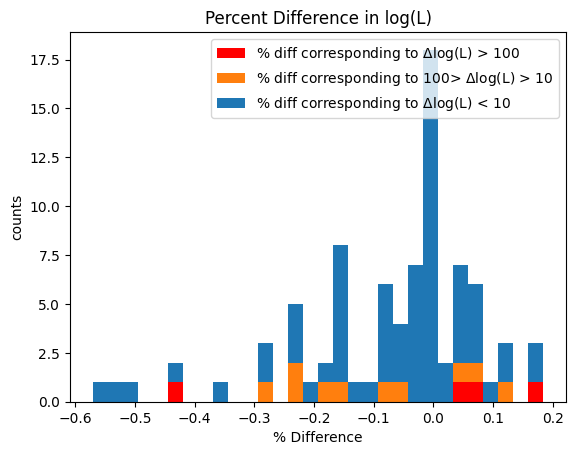

In [37]:
diff_hist, edges = np.histogram(percent_err_list, 30)
bad_diff_hist, edges2 = np.histogram(bad_percent_err_list, edges)
terrible_diff_hist, _ = np.histogram(terrible_percent_err_list, edges)

# plt.bar(edges[:-1], diff_hist, width=edges[1]-edges[0], alpha = 0.7)
# plt.bar(edges[:-1], bad_diff_hist, width = edges[1]-edges[0], color ='orange', alpha = 0.5, label = f'% diff corresponding to $\Delta$log(L) > 10')
# plt.bar(edges[:-1], terrible_diff_hist, width = edges[1]-edges[0], color ='red', alpha = 0.5, label = f'% diff corresponding to $\Delta$log(L) > 10')
colors = ['red', 'C1', 'C0']
plt.hist([terrible_percent_err_list, bad_percent_err_list, percent_err_list], edges, stacked=True, label=[f'% diff corresponding to $\Delta$log(L) > 100', f'% diff corresponding to 100> $\Delta$log(L) > 10', f'% diff corresponding to $\Delta$log(L) < 10'], color=colors)
plt.legend()
plt.title('Percent Difference in log(L)')
plt.xlabel(f'% Difference')
plt.ylabel('counts')
#plt.xlabels

In [38]:
extreme_data_x = []
extreme_data_y = []
extreme_data_z = []
normal_data_x = []
normal_data_y = []
normal_data_z = []
for key in OM_data:
    string = int(key[10:13])
    OM = int(key[14:16])
    omkey = dataclasses.ModuleKey(string, OM)
    if abs(OM_data[key][0]) > 10:
        #print(key)
        extreme_data_x.append(gcdframe['I3ModuleGeoMap'][omkey].pos.x)
        extreme_data_y.append(gcdframe['I3ModuleGeoMap'][omkey].pos.y)
        extreme_data_z.append(gcdframe['I3ModuleGeoMap'][omkey].pos.z)
    else:
        normal_data_x.append(gcdframe['I3ModuleGeoMap'][omkey].pos.x)
        normal_data_y.append(gcdframe['I3ModuleGeoMap'][omkey].pos.y)
        normal_data_z.append(gcdframe['I3ModuleGeoMap'][omkey].pos.z)

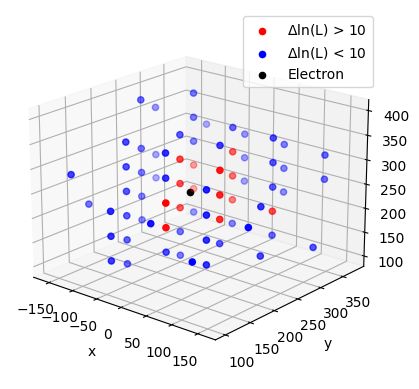

In [39]:
fig = plt.figure()
ax = fig.add_subplot(projection='3d')

ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_zlabel('z')
ax.scatter(extreme_data_x, extreme_data_y, extreme_data_z, color = 'red', label = r'$\Delta$ln(L) > 10')
ax.scatter(normal_data_x, normal_data_y, normal_data_z, color = 'blue', label = r'$\Delta$ln(L) < 10')
ax.scatter(frame18['I3MCTree'][1].pos.x, frame18['I3MCTree'][1].pos.y, frame18['I3MCTree'][1].pos.z, color = 'black', label = 'Electron')
ax.legend()
ax.view_init(20, 360 - 50, 0)

In [40]:
def check_module(string, OM):
    omkey = dataclasses.ModuleKey(string,OM)
    print(frame18['I3MCTree'][1])
    print(OM_data[f'ModuleKey({string},{OM})'])
    print(gcdframe['I3ModuleGeoMap'][omkey])


In [41]:
check_module(218,15)

[ I3Particle MajorID : 15941211553967342775
             MinorID : 614
              Zenith : 1.12255
             Azimuth : 5.03732
                   X : 2.86453
                   Y : 216.537
                   Z : 254.435
                Time : 0
              Energy : 1847.28
               Speed : 0.299792
              Length : nan
                Type : EMinus
        PDG encoding : 11
               Shape : Cascade
              Status : NotSet
            Location : InIce
]
[-6.057477235794067, -0.07665219256423016]
[I3ModuleGeo ModuleType: 40
               Position: I3Position(-80,169.948,250)
            Orientation: I3Orientation: 
    Dir: (0,0,-1)
     Up: (1,0,0)
  Right: (0,-1,0)
                 Radius: 0.2159 ]


In [42]:
min(EventData2[:,-1])

4.494409276262246

In [ ]:
t = np.linspace(4,927,2500)
def cdf(coords, Event):
    pvalues = []
    for event in Event:
        dr = displacement_magnitude(coords[0:3], np.array(event[0:3]))
        
        #dt = abs(coords[3] - event[3]) - (1.34*dr/c * 1e9)
        pdf = np.exp(splinefit.evaluate_simple([dr, t]))
        cdf = np.sum(pdf[np.searchsorted(t, event[-1]):])
        pvalues.append(cdf)

    plt.hist(pvalues, bins=np.linspace(min(pvalues),max(pvalues),50))
    plt.xlabel('CDF Value')
    plt.ylabel('Hits')
    plt.title('2D CDF Distribution')

In [44]:
from matplotlib.colors import LogNorm

In [45]:
testlist = []
for event in EventData2:
    testlist.append(displacement_magnitude(np.array([632.878, -456.534, -261.346]), np.array(event[0:3])))
print(min(testlist), max(testlist))

34.68913623856595 307.0977031223317


In [46]:
def cdf_color_plt(coords, Event):
    pvalues = []
    for event in Event:
        dr = displacement_magnitude(coords[0:3], np.array(event[0:3]))
        
        #dt = abs(coords[3] - event[3]) - (1.34*dr/c * 1e9)
        pdf = np.exp(splinefit.evaluate_simple([dr, t]))
        cdf = np.sum(pdf[np.searchsorted(t, event[-1]):])/np.sum(pdf)
        pvalues.append((cdf, dr))
    twoDary = np.array(pvalues)
    #print(twoDary)
    hist, edges = np.histogramdd(twoDary, bins=20)
    print(twoDary)
    
    fig, ax = plt.subplots()
    plot = ax.imshow(
        hist.T,                    # Transpose so axis 0 = x, axis 1 = y
        origin='lower',            # Put (0,0) at bottom-left, not top-left
        aspect='auto',
        norm=LogNorm(vmin=1, vmax=hist.max()),             # Don't force square pixels
        extent=[                   # Map pixel coords to data coords
            edges[0][0], edges[0][-1],   # x: cdf axis range
            edges[1][0], edges[1][-1]    # y: dr axis range
        ]
    )
    cbar = ax.figure.colorbar(plot, ax=ax, )
    cbar.ax.set_ylabel('Bin counts', rotation=-90, va="bottom")
    ax.set_xlabel('CDF')
    ax.set_ylabel('dr')
    plt.tight_layout()
    plt.show()

In [47]:
print(frame27['I3MCTree'][1])

[ I3Particle MajorID : 15941211553967342775
             MinorID : 956
              Zenith : 2.22391
             Azimuth : 0.938481
                   X : 632.878
                   Y : -456.534
                   Z : -261.346
                Time : 0
              Energy : 11831.7
               Speed : 0.299792
              Length : nan
                Type : EMinus
        PDG encoding : 11
               Shape : Cascade
              Status : NotSet
            Location : InIce
]


[[2.09414521e-02 1.74815896e+02]
 [4.19779872e-01 1.61654288e+02]
 [2.34404835e-01 1.34847091e+02]
 ...
 [7.99597971e-02 1.99384857e+02]
 [4.86466715e-01 2.04305026e+02]
 [9.44436108e-02 2.04253765e+02]]


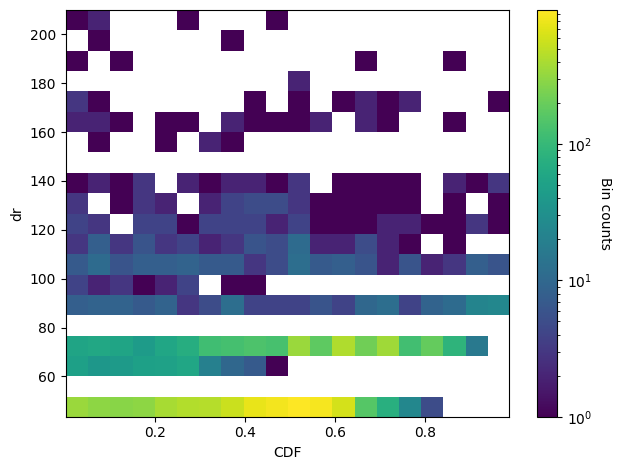

In [48]:
cdf_color_plt([2.86453,216.537,254.435, 0], EventData1)

In [49]:
print(frame128['I3MCTree'][1].pos)

I3Position(56.87,718.28,375.32)


In [50]:
len(EventData5)

53819

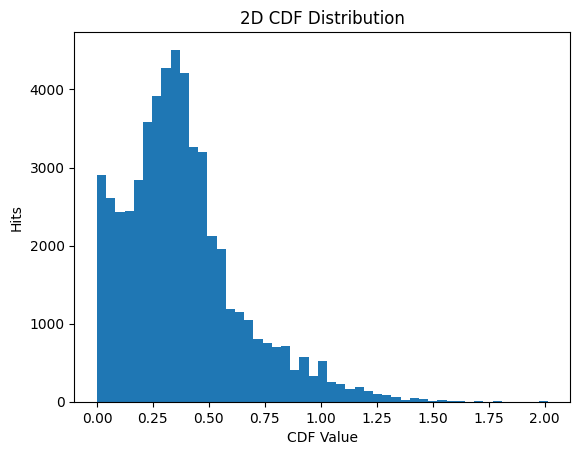

In [51]:
cdf(np.array([56.87,718.28,375.32]), EventData5)

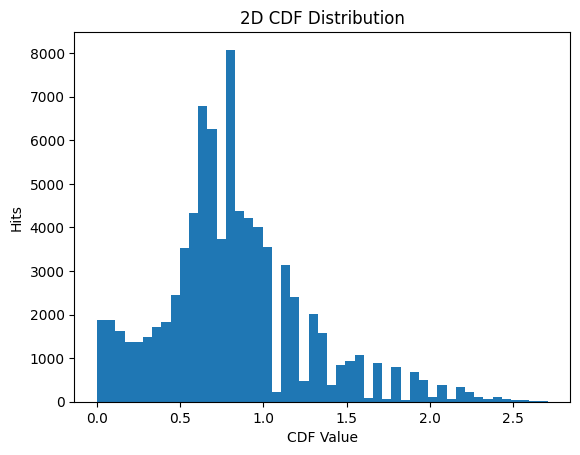

In [52]:
testval = minimizer(np.array([632.878, -456.534, -261.346, 0]), EventData2)
cdf(testval['x'], EventData2)

In [53]:
big_ary = np.array([])
for i in range(501):
    if i < 10:
        runnumber = '00' + str(i)
    elif i < 100:
        runnumber = '0' + str(i)
    else:
        runnumber = str(i)
    if os.path.isfile(f'/mnt/scratch/dillonb5/3d_logL/delta_ary_{runnumber}.npy'):
        #print(runnumber)
        ary = np.load(f'/mnt/scratch/dillonb5/3d_logL/delta_ary_{runnumber}.npy')
    
        mask = ary != 0
        ary_masked = ary[mask]
        big_ary = np.concatenate((big_ary, ary_masked))

print(big_ary)

[  1.83172131 412.96348178   2.75431466 ...   3.69030142   2.6641202
   7.27377534]


Text(0.5, 0, 'Delta Log(L)')

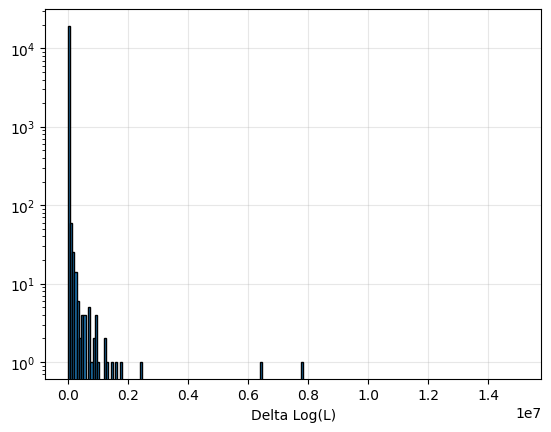

In [54]:
#ary = np.load(f'/mnt/scratch/dillonb5/delta_ary_012.npy')
bins_linear = np.linspace(0, 1.5e7, 200)

hist, edges = np.histogram(big_ary, bins_linear)
#plt.figure(figsize=(10,7))
plt.grid(alpha = 0.3, zorder = 0)
plt.bar(edges[:-1], hist, width = edges[1] - edges[0], ec = 'black', align='edge', zorder = 3)
#plt.xticks(edges[:-1])
plt.yscale('log')
plt.xlabel('Delta Log(L)')

#plt.xscale('log')

In [55]:
def evaluate_frame(frame):
    if (len(frame['I3MCTree']) != 0) and (len(frame['I3Photons']) != 0):
        EventData = datacollect(frame)
        truth = np.array([frame['I3MCTree'][1].pos.x, frame['I3MCTree'][1].pos.y, frame['I3MCTree'][1].pos.z, frame['I3MCTree'][1].time])
        model = minimizer(truth, EventData)
        model_likelihood = Likelihood(model['x'], EventData)
        truth_likelihood = Likelihood(truth, EventData)
        return (truth_likelihood - model_likelihood)


In [56]:
file_012 = dataio.I3File('../nue_data/gen_012.i3.zst')
frames = []
for frame in file_012:
    frames.append(frame)
frames = frames[1:]